# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Aditya Nurahya
- Email: adityanurahya@gmail.com
- Id Dicoding: adityanurahya

## Business Understanding

Jaya Jaya Institut merupakan institusi pendidikan perguruan yang telah berdiri sejak tahun 2000 dan telah mencetak banyak lulusan dengan reputasi yang sangat baik. Namun, terdapat banyak siswa yang tidak menyelesaikan pendidikannya (dropout). Tingginya angka dropout menjadi masalah serius bagi institusi.

**Tujuan:** Mendeteksi sedini mungkin siswa yang berpotensi dropout sehingga dapat diberikan bimbingan khusus.

### Permasalahan Bisnis
1. Bagaimana cara mengidentifikasi siswa yang berpotensi dropout sejak dini?
2. Faktor-faktor apa saja yang paling berpengaruh terhadap keputusan siswa untuk dropout?
3. Bagaimana cara memonitor performa siswa secara efektif?

### Cakupan Proyek
1. Analisis eksplorasi data (EDA) untuk memahami karakteristik siswa dropout vs graduate.
2. Pembangunan model machine learning untuk prediksi dropout.
3. Pembuatan dashboard monitoring performa siswa.
4. Deployment prototype sistem prediksi menggunakan Streamlit.

## Persiapan

### Menyiapkan library yang dibutuhkan

Berikut adalah library yang digunakan dalam proyek ini:

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
import warnings
warnings.filterwarnings('ignore')

print("Library berhasil diimpor!")

Library berhasil diimpor!


### Menyiapkan data yang akan digunakan

Sumber data: [UCI Machine Learning Repository - Predict students' dropout and academic success](https://doi.org/10.24432/C5MC89)

Data disimpan dalam file `data.csv` dengan separator semicolon (`;`).

In [18]:
# Memuat dataset
df = pd.read_csv('data.csv', sep=';')
print(f"Dataset berhasil dimuat dengan {df.shape[0]} baris dan {df.shape[1]} kolom.")
df.head()

Dataset berhasil dimuat dengan 4424 baris dan 37 kolom.


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

Pada tahap ini kita akan memahami struktur, distribusi, dan karakteristik data. Dataset berisi informasi tentang siswa yang terdaftar di berbagai program sarjana, termasuk jalur akademik, demografi, faktor sosial-ekonomi, serta performa akademik di semester 1 dan 2.

Variabel target (`Status`) terdiri dari 3 kategori:
- **Dropout**: Siswa yang tidak menyelesaikan pendidikan
- **Enrolled**: Siswa yang masih aktif terdaftar
- **Graduate**: Siswa yang berhasil lulus

In [3]:
# Informasi dataset
print("=== Informasi Dataset ===")
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")
print(f"\n=== Tipe Data ===")
print(df.dtypes)
print(f"\n=== Statistik Deskriptif ===")
df.describe()

=== Informasi Dataset ===
Jumlah baris: 4424
Jumlah kolom: 37

=== Tipe Data ===
Marital_status                                    int64
Application_mode                                  int64
Application_order                                 int64
Course                                            int64
Daytime_evening_attendance                        int64
Previous_qualification                            int64
Previous_qualification_grade                    float64
Nacionality                                       int64
Mothers_qualification                             int64
Fathers_qualification                             int64
Mothers_occupation                                int64
Fathers_occupation                                int64
Admission_grade                                 float64
Displaced                                         int64
Educational_special_needs                         int64
Debtor                                            int64
Tuition_fees_up_to_date

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [4]:
# Cek missing values
print("=== Missing Values ===")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

=== Missing Values ===
Marital_status                                  0
Application_mode                                0
Application_order                               0
Course                                          0
Daytime_evening_attendance                      0
Previous_qualification                          0
Previous_qualification_grade                    0
Nacionality                                     0
Mothers_qualification                           0
Fathers_qualification                           0
Mothers_occupation                              0
Fathers_occupation                              0
Admission_grade                                 0
Displaced                                       0
Educational_special_needs                       0
Debtor                                          0
Tuition_fees_up_to_date                         0
Gender                                          0
Scholarship_holder                              0
Age_at_enrollment          

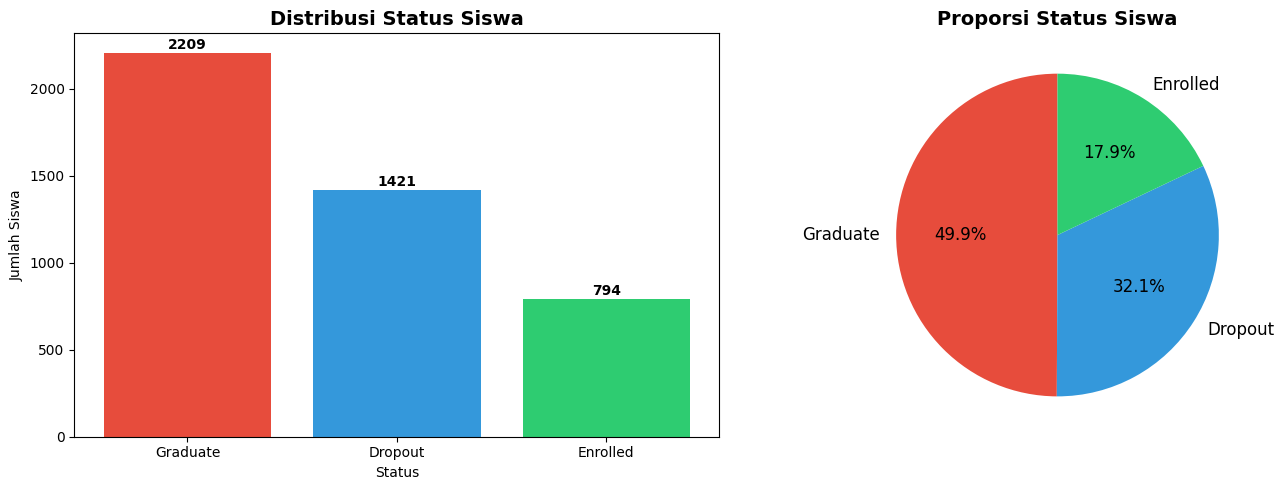


Persentase Dropout: 32.1%
Persentase Enrolled: 17.9%
Persentase Graduate: 49.9%


In [5]:
# Distribusi variabel target (Status)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Countplot
status_counts = df['Status'].value_counts()
colors = ['#e74c3c', '#3498db', '#2ecc71']
axes[0].bar(status_counts.index, status_counts.values, color=colors)
axes[0].set_title('Distribusi Status Siswa', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Jumlah Siswa')
for i, v in enumerate(status_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Proporsi Status Siswa', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nPersentase Dropout: {status_counts.get('Dropout', 0)/len(df)*100:.1f}%")
print(f"Persentase Enrolled: {status_counts.get('Enrolled', 0)/len(df)*100:.1f}%")
print(f"Persentase Graduate: {status_counts.get('Graduate', 0)/len(df)*100:.1f}%")

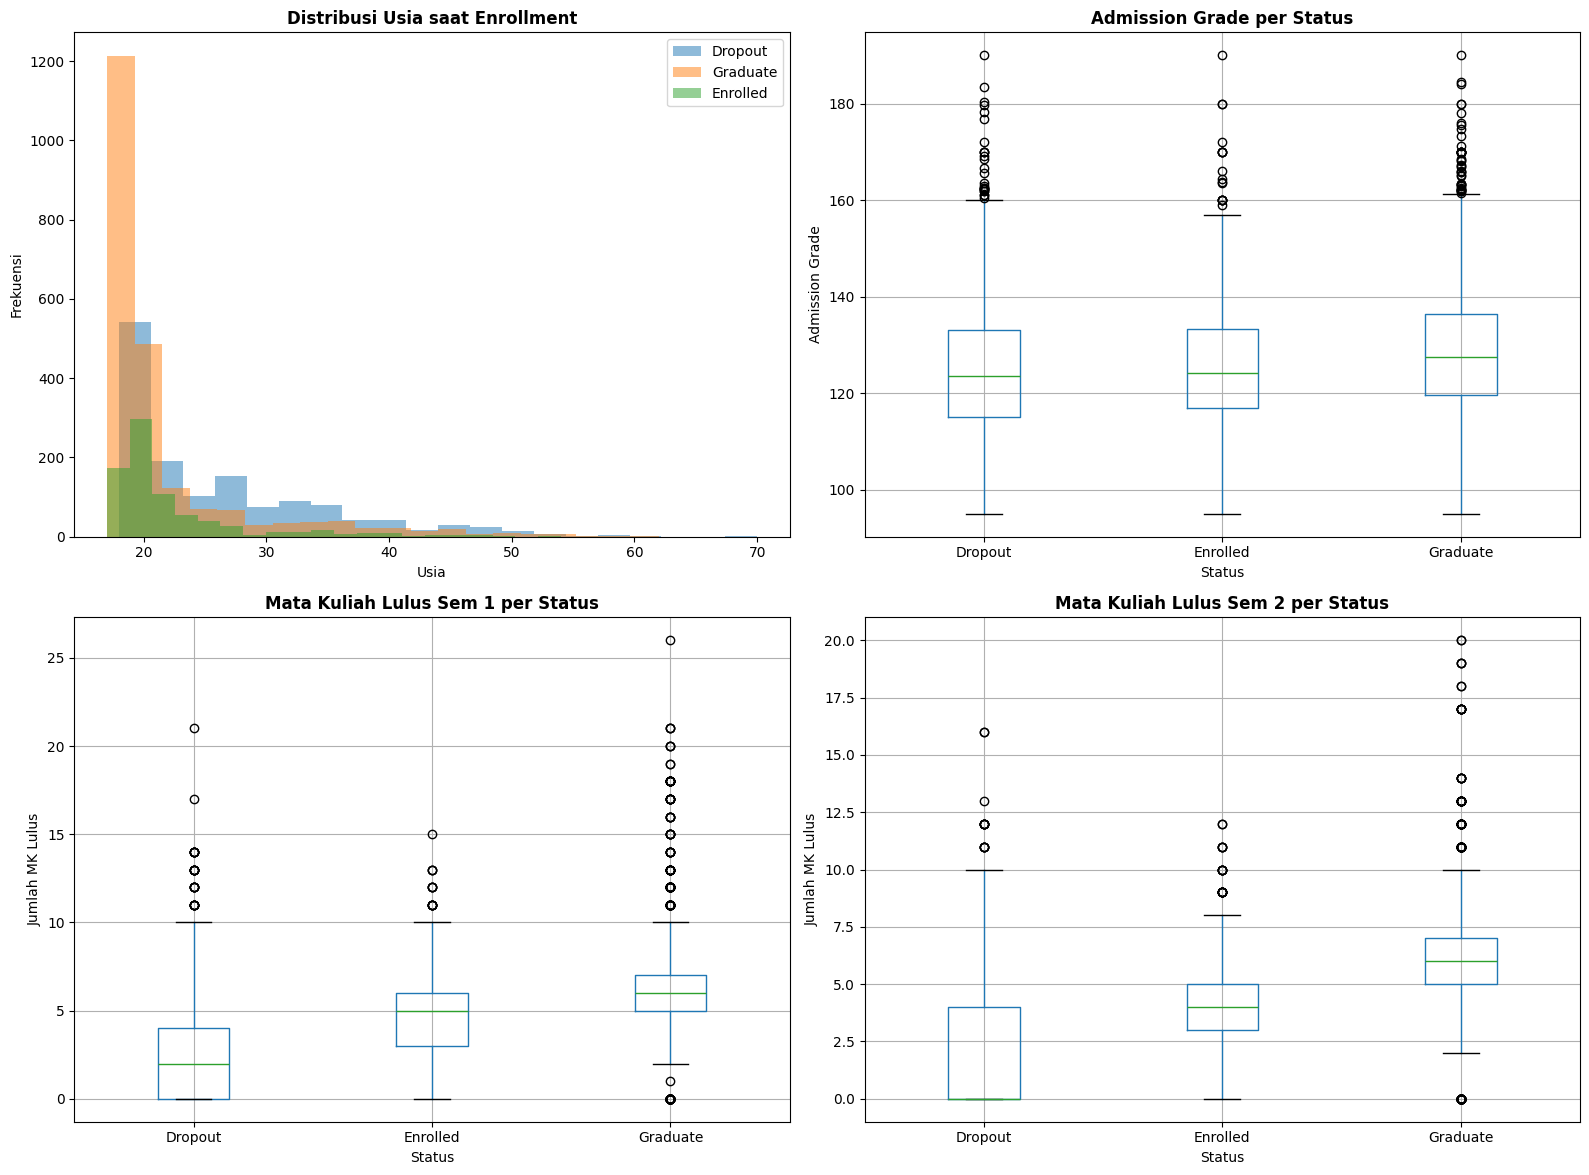

In [6]:
# Analisis korelasi fitur numerik dengan status
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Distribusi usia saat enrollment berdasarkan status
for status in df['Status'].unique():
    subset = df[df['Status'] == status]
    axes[0, 0].hist(subset['Age_at_enrollment'], alpha=0.5, label=status, bins=20)
axes[0, 0].set_title('Distribusi Usia saat Enrollment', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Usia')
axes[0, 0].set_ylabel('Frekuensi')
axes[0, 0].legend()

# Admission grade berdasarkan status
df.boxplot(column='Admission_grade', by='Status', ax=axes[0, 1])
axes[0, 1].set_title('Admission Grade per Status', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Status')
axes[0, 1].set_ylabel('Admission Grade')
plt.suptitle('')

# Curricular units 1st sem approved berdasarkan status
df.boxplot(column='Curricular_units_1st_sem_approved', by='Status', ax=axes[1, 0])
axes[1, 0].set_title('Mata Kuliah Lulus Sem 1 per Status', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Status')
axes[1, 0].set_ylabel('Jumlah MK Lulus')
plt.suptitle('')

# Curricular units 2nd sem approved berdasarkan status
df.boxplot(column='Curricular_units_2nd_sem_approved', by='Status', ax=axes[1, 1])
axes[1, 1].set_title('Mata Kuliah Lulus Sem 2 per Status', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Status')
axes[1, 1].set_ylabel('Jumlah MK Lulus')
plt.suptitle('')

plt.tight_layout()
plt.show()

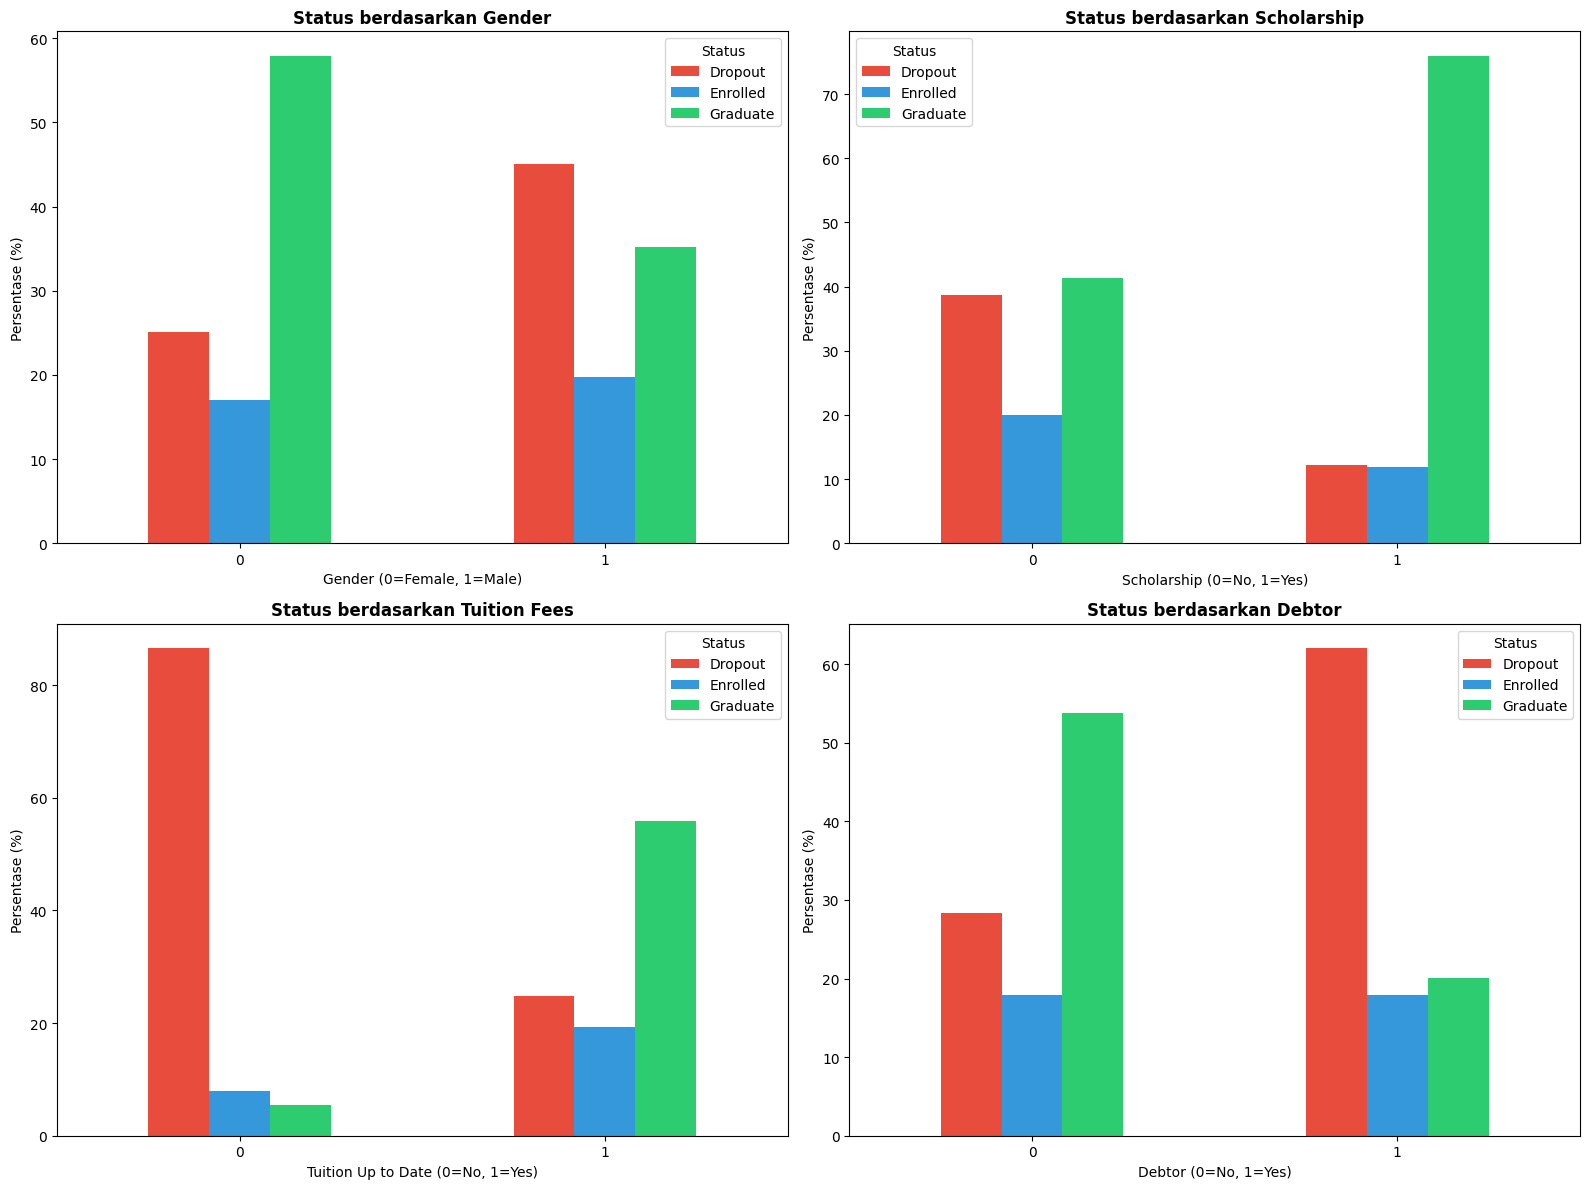

In [7]:
# Analisis fitur kategorikal penting
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Gender vs Status
gender_status = pd.crosstab(df['Gender'], df['Status'], normalize='index') * 100
gender_status.plot(kind='bar', ax=axes[0, 0], color=colors)
axes[0, 0].set_title('Status berdasarkan Gender', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Gender (0=Female, 1=Male)')
axes[0, 0].set_ylabel('Persentase (%)')
axes[0, 0].legend(title='Status')
axes[0, 0].tick_params(axis='x', rotation=0)

# Scholarship holder vs Status
scholar_status = pd.crosstab(df['Scholarship_holder'], df['Status'], normalize='index') * 100
scholar_status.plot(kind='bar', ax=axes[0, 1], color=colors)
axes[0, 1].set_title('Status berdasarkan Scholarship', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Scholarship (0=No, 1=Yes)')
axes[0, 1].set_ylabel('Persentase (%)')
axes[0, 1].legend(title='Status')
axes[0, 1].tick_params(axis='x', rotation=0)

# Tuition fees up to date vs Status
tuition_status = pd.crosstab(df['Tuition_fees_up_to_date'], df['Status'], normalize='index') * 100
tuition_status.plot(kind='bar', ax=axes[1, 0], color=colors)
axes[1, 0].set_title('Status berdasarkan Tuition Fees', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Tuition Up to Date (0=No, 1=Yes)')
axes[1, 0].set_ylabel('Persentase (%)')
axes[1, 0].legend(title='Status')
axes[1, 0].tick_params(axis='x', rotation=0)

# Debtor vs Status
debtor_status = pd.crosstab(df['Debtor'], df['Status'], normalize='index') * 100
debtor_status.plot(kind='bar', ax=axes[1, 1], color=colors)
axes[1, 1].set_title('Status berdasarkan Debtor', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Debtor (0=No, 1=Yes)')
axes[1, 1].set_ylabel('Persentase (%)')
axes[1, 1].legend(title='Status')
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

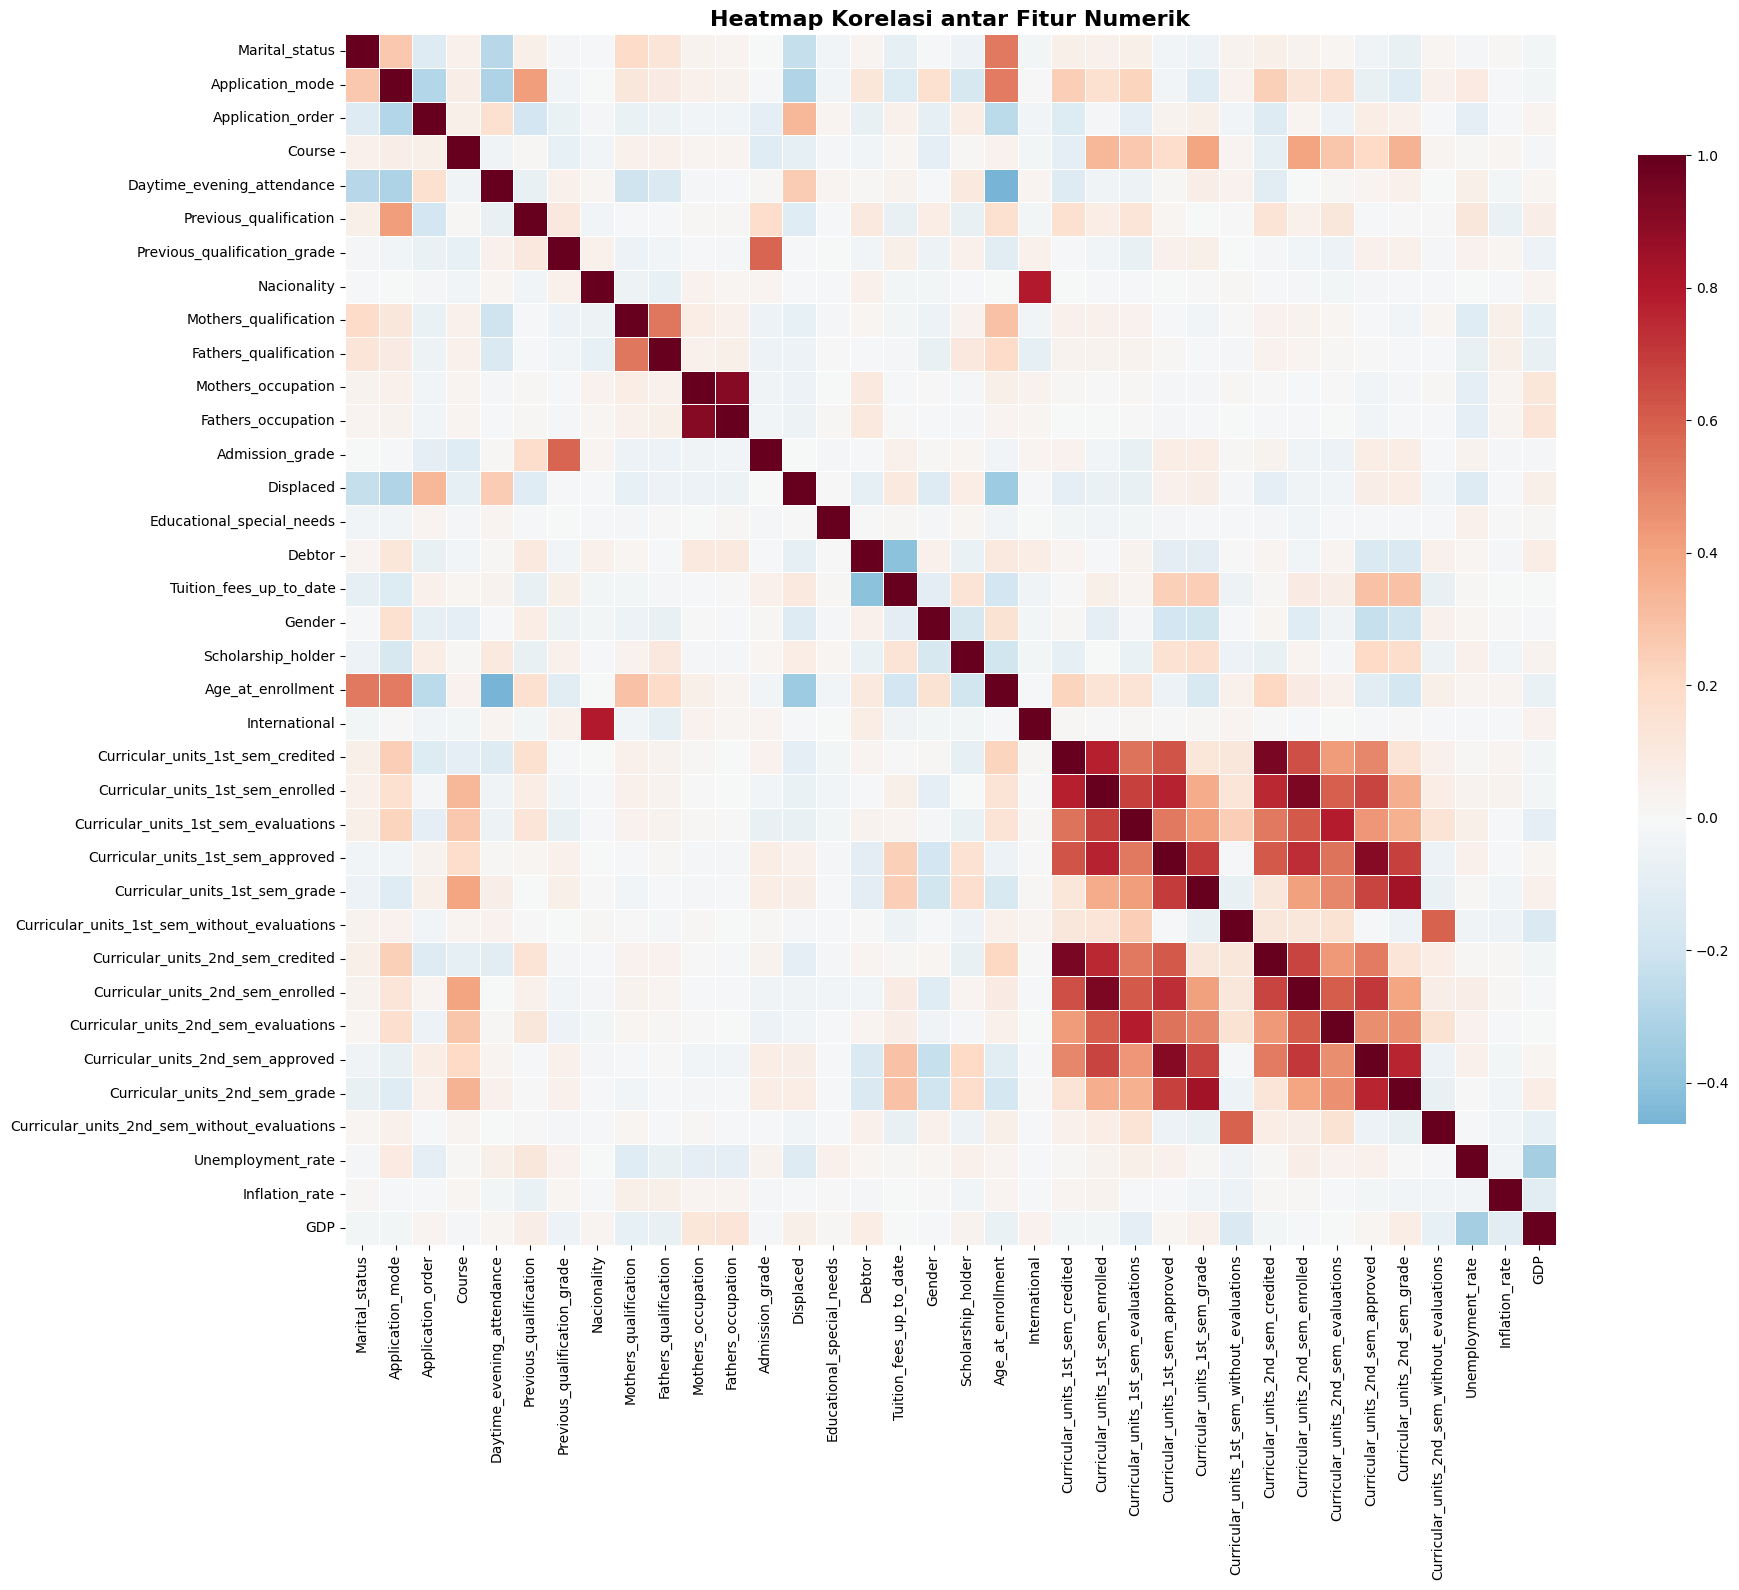

In [8]:
# Heatmap korelasi fitur numerik
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, cmap='RdBu_r', center=0, fmt='.1f',
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Heatmap Korelasi antar Fitur Numerik', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Insight dari Data Understanding:
1. **Distribusi Target**: Dataset kemungkinan imbalanced, dengan proporsi Dropout, Enrolled, dan Graduate yang berbeda.
2. **Usia**: Siswa yang dropout cenderung memiliki usia yang lebih tinggi saat enrollment.
3. **Performa Akademik**: Jumlah mata kuliah yang lulus (approved) di semester 1 dan 2 sangat berkorelasi dengan status siswa - siswa dropout cenderung memiliki jumlah MK lulus yang sangat rendah.
4. **Faktor Finansial**: Status pembayaran tuition dan status debtor berpengaruh terhadap kemungkinan dropout.
5. **Scholarship**: Penerima beasiswa cenderung memiliki tingkat kelulusan yang lebih tinggi.

## Data Preparation / Preprocessing

Pada tahap ini dilakukan:
1. **Filtering data**: Menghapus data siswa dengan status "Enrolled" karena belum memiliki label akhir. Model hanya dilatih menggunakan data siswa dengan status **Dropout** dan **Graduate**.
2. Encoding variabel target (Status) menjadi numerik menggunakan LabelEncoder.
3. Feature scaling menggunakan StandardScaler.
4. Split data menjadi training dan testing set (80:20).

> **Catatan:** Data siswa dengan status Enrolled dapat digunakan pada tahap inferensi/prediksi untuk memprediksi kemungkinan status akhir mereka di masa depan.

In [19]:
# Data Preparation
# Membuat salinan dataframe
df_processed = df.copy()

# Filter: hanya gunakan data Dropout dan Graduate untuk training
# Status "Enrolled" tidak digunakan karena belum memiliki label akhir
df_enrolled = df_processed[df_processed['Status'] == 'Enrolled'].copy()
df_processed = df_processed[df_processed['Status'].isin(['Dropout', 'Graduate'])].copy()

print(f"Data sebelum filtering: {len(df)} baris")
print(f"Data Enrolled (disimpan untuk inferensi): {len(df_enrolled)} baris")
print(f"Data setelah filtering (Dropout + Graduate): {len(df_processed)} baris")

# Encode target variable
label_encoder = LabelEncoder()
df_processed['Status_encoded'] = label_encoder.fit_transform(df_processed['Status'])
print("\nLabel Encoding:")
for i, cls in enumerate(label_encoder.classes_):
    print(f"  {cls} -> {i}")

# Memisahkan fitur dan target
X = df_processed.drop(columns=['Status', 'Status_encoded'])
y = df_processed['Status_encoded']

print(f"\nJumlah fitur: {X.shape[1]}")
print(f"Fitur: {list(X.columns)}")
print(f"\nDistribusi target:")
print(y.value_counts().sort_index())

Data sebelum filtering: 4424 baris
Data Enrolled (disimpan untuk inferensi): 794 baris
Data setelah filtering (Dropout + Graduate): 3630 baris

Label Encoding:
  Dropout -> 0
  Graduate -> 1

Jumlah fitur: 36
Fitur: ['Marital_status', 'Application_mode', 'Application_order', 'Course', 'Daytime_evening_attendance', 'Previous_qualification', 'Previous_qualification_grade', 'Nacionality', 'Mothers_qualification', 'Fathers_qualification', 'Mothers_occupation', 'Fathers_occupation', 'Admission_grade', 'Displaced', 'Educational_special_needs', 'Debtor', 'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder', 'Age_at_enrollment', 'International', 'Curricular_units_1st_sem_credited', 'Curricular_units_1st_sem_enrolled', 'Curricular_units_1st_sem_evaluations', 'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade', 'Curricular_units_1st_sem_without_evaluations', 'Curricular_units_2nd_sem_credited', 'Curricular_units_2nd_sem_enrolled', 'Curricular_units_2nd_sem_evaluations', 'C

In [20]:
# Split data menjadi training dan testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Ukuran data training: {X_train.shape}")
print(f"Ukuran data testing: {X_test.shape}")
print(f"\nDistribusi target pada data training:")
print(pd.Series(y_train).value_counts().sort_index())
print(f"\nDistribusi target pada data testing:")
print(pd.Series(y_test).value_counts().sort_index())

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Simpan nama fitur untuk digunakan nanti
feature_names = X.columns.tolist()

print(f"\nFeature scaling selesai. Data siap untuk modeling.")

Ukuran data training: (2904, 36)
Ukuran data testing: (726, 36)

Distribusi target pada data training:
Status_encoded
0    1137
1    1767
Name: count, dtype: int64

Distribusi target pada data testing:
Status_encoded
0    284
1    442
Name: count, dtype: int64

Feature scaling selesai. Data siap untuk modeling.


## Modeling

Pada tahap ini kita akan melatih dua model machine learning untuk klasifikasi biner (Dropout vs Graduate):
1. **Random Forest Classifier** - Ensemble learning berbasis decision tree yang robust terhadap overfitting.
2. **Gradient Boosting Classifier** - Ensemble learning yang membangun model secara sequential.

Kita akan memilih model terbaik berdasarkan performa pada data testing.

In [21]:
# Model 1: Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)
rf_accuracy = accuracy_score(y_test, rf_pred)

print("=== Random Forest Classifier ===")
print(f"Accuracy: {rf_accuracy:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=label_encoder.classes_))

=== Random Forest Classifier ===
Accuracy: 0.9077

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.95      0.81      0.87       284
    Graduate       0.89      0.97      0.93       442

    accuracy                           0.91       726
   macro avg       0.92      0.89      0.90       726
weighted avg       0.91      0.91      0.91       726



In [22]:
# Model 2: Gradient Boosting Classifier
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
gb_model.fit(X_train_scaled, y_train)
gb_pred = gb_model.predict(X_test_scaled)
gb_accuracy = accuracy_score(y_test, gb_pred)

print("=== Gradient Boosting Classifier ===")
print(f"Accuracy: {gb_accuracy:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, gb_pred, target_names=label_encoder.classes_))

=== Gradient Boosting Classifier ===
Accuracy: 0.9063

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.94      0.81      0.87       284
    Graduate       0.89      0.97      0.93       442

    accuracy                           0.91       726
   macro avg       0.92      0.89      0.90       726
weighted avg       0.91      0.91      0.90       726



In [23]:
# Perbandingan Model
print("=== Perbandingan Model ===")
print(f"Random Forest Accuracy:     {rf_accuracy:.4f}")
print(f"Gradient Boosting Accuracy: {gb_accuracy:.4f}")

# Pilih model terbaik
if gb_accuracy >= rf_accuracy:
    best_model = gb_model
    best_name = "Gradient Boosting"
    best_pred = gb_pred
    best_accuracy = gb_accuracy
else:
    best_model = rf_model
    best_name = "Random Forest"
    best_pred = rf_pred
    best_accuracy = rf_accuracy

print(f"\nModel terbaik: {best_name} dengan accuracy {best_accuracy:.4f}")

=== Perbandingan Model ===
Random Forest Accuracy:     0.9077
Gradient Boosting Accuracy: 0.9063

Model terbaik: Random Forest dengan accuracy 0.9077


## Evaluation

Evaluasi model terbaik menggunakan confusion matrix, classification report, dan analisis feature importance.

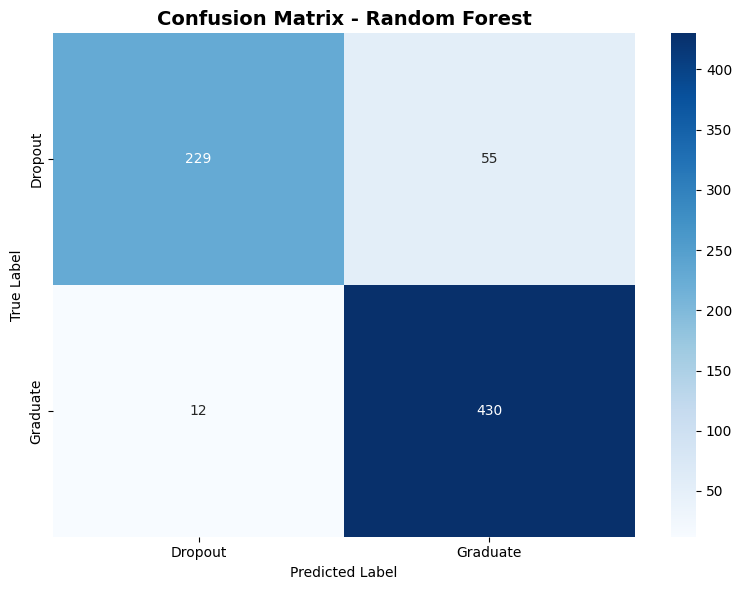


=== Classification Report - Random Forest ===
              precision    recall  f1-score   support

     Dropout       0.95      0.81      0.87       284
    Graduate       0.89      0.97      0.93       442

    accuracy                           0.91       726
   macro avg       0.92      0.89      0.90       726
weighted avg       0.91      0.91      0.91       726



In [24]:
# Confusion Matrix untuk model terbaik
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_, ax=ax)
ax.set_title(f'Confusion Matrix - {best_name}', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.show()

print(f"\n=== Classification Report - {best_name} ===")
print(classification_report(y_test, best_pred, target_names=label_encoder.classes_))

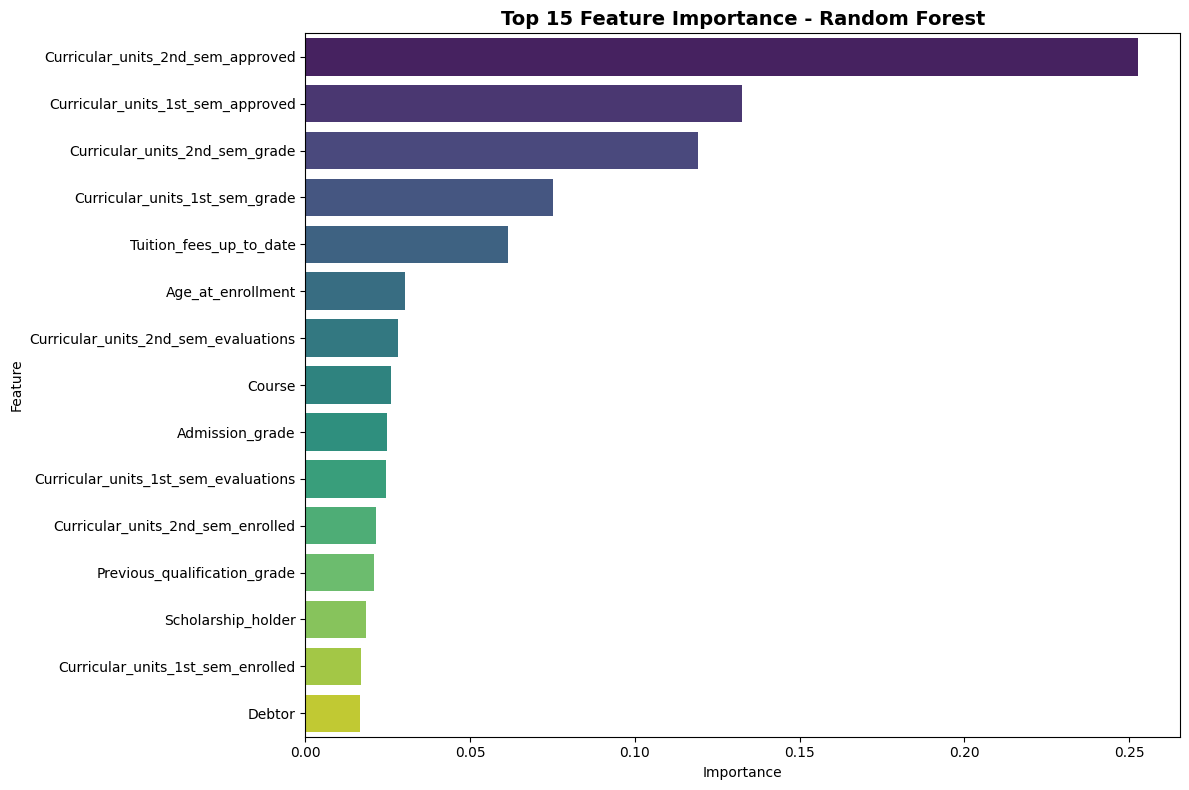


Top 10 fitur terpenting:
  Curricular_units_2nd_sem_approved: 0.2528
  Curricular_units_1st_sem_approved: 0.1324
  Curricular_units_2nd_sem_grade: 0.1192
  Curricular_units_1st_sem_grade: 0.0752
  Tuition_fees_up_to_date: 0.0614
  Age_at_enrollment: 0.0301
  Curricular_units_2nd_sem_evaluations: 0.0282
  Course: 0.0258
  Admission_grade: 0.0247
  Curricular_units_1st_sem_evaluations: 0.0244


In [25]:
# Feature Importance
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
top_n = 15
sns.barplot(data=feature_importance.head(top_n), x='importance', y='feature', palette='viridis')
plt.title(f'Top {top_n} Feature Importance - {best_name}', fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print(f"\nTop 10 fitur terpenting:")
for idx, row in feature_importance.head(10).iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")

## Save Model dan Artifacts

Menyimpan model, scaler, label encoder, dan nama fitur untuk digunakan pada prototype Streamlit.

In [26]:
import os

# Buat folder model jika belum ada
os.makedirs('model', exist_ok=True)

# Simpan model, scaler, dan label encoder
joblib.dump(best_model, 'model/best_model.joblib')
joblib.dump(scaler, 'model/scaler.joblib')
joblib.dump(label_encoder, 'model/label_encoder.joblib')
joblib.dump(feature_names, 'model/feature_names.joblib')

print("Model dan artifacts berhasil disimpan di folder 'model/':")
print("  - model/best_model.joblib")
print("  - model/scaler.joblib")
print("  - model/label_encoder.joblib")
print("  - model/feature_names.joblib")
print(f"\nModel yang disimpan: {best_name} (Accuracy: {best_accuracy:.4f})")

Model dan artifacts berhasil disimpan di folder 'model/':
  - model/best_model.joblib
  - model/scaler.joblib
  - model/label_encoder.joblib
  - model/feature_names.joblib

Model yang disimpan: Random Forest (Accuracy: 0.9077)


## Inferensi pada Data Enrolled (Optional)

Menggunakan model yang telah dilatih untuk memprediksi kemungkinan status akhir siswa yang masih berstatus Enrolled.

In [27]:
# Inferensi pada data siswa yang masih Enrolled
if len(df_enrolled) > 0:
    X_enrolled = df_enrolled.drop(columns=['Status'])
    X_enrolled_scaled = scaler.transform(X_enrolled)
    
    enrolled_pred = best_model.predict(X_enrolled_scaled)
    enrolled_pred_labels = label_encoder.inverse_transform(enrolled_pred)
    enrolled_proba = best_model.predict_proba(X_enrolled_scaled)
    
    df_enrolled_result = df_enrolled[['Age_at_enrollment', 'Gender', 'Scholarship_holder', 
                                       'Tuition_fees_up_to_date', 'Curricular_units_1st_sem_approved',
                                       'Curricular_units_2nd_sem_approved']].copy()
    df_enrolled_result['Predicted_Status'] = enrolled_pred_labels
    df_enrolled_result['Dropout_Probability'] = enrolled_proba[:, 0]
    df_enrolled_result['Graduate_Probability'] = enrolled_proba[:, 1]
    
    print(f"=== Hasil Prediksi Siswa Enrolled ===")
    print(f"Total siswa Enrolled: {len(df_enrolled)}")
    print(f"\nDistribusi prediksi:")
    print(pd.Series(enrolled_pred_labels).value_counts())
    print(f"\nSample hasil prediksi (10 siswa pertama):")
    print(df_enrolled_result.head(10).to_string())
else:
    print("Tidak ada data siswa Enrolled.")

=== Hasil Prediksi Siswa Enrolled ===
Total siswa Enrolled: 794

Distribusi prediksi:
Graduate    439
Dropout     355
Name: count, dtype: int64

Sample hasil prediksi (10 siswa pertama):
    Age_at_enrollment  Gender  Scholarship_holder  Tuition_fees_up_to_date  Curricular_units_1st_sem_approved  Curricular_units_2nd_sem_approved Predicted_Status  Dropout_Probability  Graduate_Probability
16                 18       0                   0                        1                                  1                                  2          Dropout             0.930911              0.069089
19                 18       0                   0                        1                                  6                                  6         Graduate             0.148530              0.851470
21                 20       0                   0                        1                                  7                                  8         Graduate             0.148034              0.